In [11]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn

from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common import results_plotter

import matplotlib.pyplot as plt
import os
import yaml
import pandas as pd

import collections
import math

In [2]:
log_dir = "logs_nn"
os.makedirs(log_dir, exist_ok=True)

# Wrap Dynamic Model as Gym Environment

In [3]:
# ------------------------------------------------------------------
# Simple 3-Layer MLP
# ------------------------------------------------------------------
class MLP3(nn.Module):
    """A basic 3-layer perceptron: Input -> hidden1 -> hidden2 -> output.

    hidden_sizes: tuple (h1, h2)
    activation: callable returning nn.Module, e.g., nn.ReLU
    """
    def __init__(self, in_dim: int, out_dim: int, hidden_sizes=(128, 64), activation=nn.ReLU):
        super().__init__()
        h1, h2 = hidden_sizes
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1),
            activation(),
            nn.Linear(h1, h2),
            activation(),
            nn.Linear(h2, out_dim),
        )

    def forward(self, x):
        return self.net(x)

class CartPoleNNEnv (gym.Env):
    
    def __init__(self, model_filename="dyn_model.pth", stats_filename="dyn_model_stats.yaml", window_size=4):
        self.dyn_model = torch.load(model_filename, weights_only=False)
        self.device = next(self.dyn_model.parameters()).device
        self.window_size=window_size

        # load normalization constants
        with open(stats_filename, 'r') as f:
            stats = yaml.safe_load(f)
    
        # Convert back to tensors
        self.x_mean = torch.tensor(stats['x_mean'], dtype=torch.float32).to(self.device)
        self.x_std  = torch.tensor(stats['x_std'], dtype=torch.float32).to(self.device)
        self.y_mean = torch.tensor(stats['y_mean'], dtype=torch.float32).to(self.device)
        self.y_std  = torch.tensor(stats['y_std'], dtype=torch.float32).to(self.device)
        
        # FIFO-buffer that keeps the neural state
        self.stateBuffer = collections.deque(maxlen=window_size)
        
        # Angle at which to fail the episode
        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = 2.4
        
        # Angle limit set to 2 * theta_threshold_radians so failing observation
        # is still within bounds.
        high = np.array([self.x_threshold * 2,
                         np.finfo(np.float32).max,
                         self.theta_threshold_radians * 2,
                         np.finfo(np.float32).max],
                        dtype=np.float32)

        self.action_space = gym.spaces.Discrete(2)
        self.observation_space = gym.spaces.Box(-high, high, dtype=np.float32)

    def step (self, action):
        
        self.steps +=1
        
        # append last state + new action to state buffer
        netInput = [self.currentState[0], self.currentState[1],
                    self.currentState[2], self.currentState[3], 
                    action]
        self.stateBuffer.append (np.float64(netInput))
        state = np.array([list(self.stateBuffer)])
        
        # NN inference
        with torch.no_grad():
            state_tensor = torch.flatten(torch.tensor(state, dtype=torch.float32)).to(self.device)
            state_tensor_norm = (state_tensor - self.x_mean) / self.x_std
            y_pred_norm = self.dyn_model(state_tensor_norm)
            y_pred = y_pred_norm * self.y_std + self.y_mean
        netOutput = y_pred.squeeze(0).cpu().numpy()
                
        # retrieve new state
        self.currentState = np.float64([netOutput[0], netOutput[1], 
                                         netOutput[2], netOutput[3]])
        # check for episode termination
        cartPos = netOutput[0]
        pendPosDeg = np.degrees(netOutput[2])
        pendPosRad = netOutput[2]
        
        done=False
        if abs(cartPos) >= 2.4 or abs(pendPosDeg) >= 12 or self.steps > 200:
            done = True
            
        # compute reward
        rewardAngle = np.cos(pendPosRad)
        rewardPos = -abs(cartPos)
        
        return self.currentState, rewardAngle + rewardPos, done, False, {}
    
    def render (self):
        pass
    
    def reset(self, seed=0): 
        self.steps = 0
        
        # draw initial state
        initCartPos = 2. *np.random.random () - 1 # [-0.05, 0.05]
        initCartVel = 0
        initPendPos = 0
        initPendVel = 0
        
        # fill initial state
        for i in range (self.window_size):
            initState = np.float64([initCartPos, initCartVel, initPendPos, initPendVel, self.action_space.sample()])
            self.stateBuffer.append (initState)
            
        self.currentState = initState[0:4]
        
        return self.currentState, {}

# Instantiate monitored Gym environment

In [4]:
print("✓ CartPoleNNEnv environment class defined and ready for use")

✓ CartPoleNNEnv environment class defined and ready for use


# Learn policy

### 1) Callback function for saving best model during training

In [5]:
from stable_baselines3.common.callbacks import BaseCallback
class SaveOnBestTrainingRewardCallback(BaseCallback):
    """
    Callback for saving a model (the check is done every ``check_freq`` steps)
    based on the training reward (in practice, we recommend using ``EvalCallback``).

    :param check_freq: (int)
    :param avg_episodes: (int) average over the past n episodes (default: 100)
    :param log_dir: (str) Path to the folder where the model will be saved.
      It must contains the file created by the ``Monitor`` wrapper.
    :param verbose: (int)
    :param vec_norm_env: (VecNormalize) stable-baselines VecNormalize object (contains Gym env)
    """
    def __init__(self, check_freq: int, log_dir: str, verbose=1, avg_episodes=100, vec_norm_env=None):
        super(SaveOnBestTrainingRewardCallback, self).__init__(verbose)
        self.check_freq = check_freq
        self.log_dir = log_dir
        self.save_path = os.path.join(log_dir, 'best_model_nn')
        self.best_mean_reward = -np.inf
        self.best_timestep = -np.inf
        self.vec_norm_env = vec_norm_env
        self.avg_episodes = avg_episodes

    def _init_callback(self) -> None:
        # Create folder if needed
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:

            # Retrieve training reward - handle case where monitor files don't exist yet
            try:
                x, y = ts2xy(load_results(self.log_dir), 'timesteps')
            except Exception as e:
                # Monitor files not created yet, skip this callback check
                if self.verbose > 0:
                    print(f"Num timesteps: {self.num_timesteps} (waiting for monitor files...)")
                return True
            
            if len(x) > 0:
                # Mean training reward over the last avg_episodes episodes
                mean_reward = np.mean(y[-self.avg_episodes:])

                # New best model, you could save the agent here
                if mean_reward > self.best_mean_reward:
                    self.best_mean_reward = mean_reward
                    self.best_timestep = self.num_timesteps
                    # Example for saving best model
                    if self.verbose > 0:
                        print("Saving new best model to {}".format(self.save_path))
                    self.model.save(self.save_path)
                    if self.vec_norm_env is not None: 
                        self.vec_norm_env.save ("%s.env_normalizations" % self.save_path)

                if self.verbose > 0:
                    print("Num timesteps: {}".format(self.num_timesteps))
                    print("Best mean reward: {:.2f} (ts={}) - Last mean reward per episode: {:.2f}".format(self.best_mean_reward, self.best_timestep, mean_reward))


        return True

### 2) Train Policy

In [6]:
# ============================================================================
# STEP 2: Train PPO Policy for Each Dynamic Model (N = 50, 100, 200, 500, 1000)
# ============================================================================
# Train one PPO policy per dynamic model with consistent hyperparameters

dataset_sizes = [50, 100, 200, 500, 1000]
time_steps = 101000  # Consistent training budget across all models

# Store results for comparison
ppo_results = {}

for N in dataset_sizes:
    print(f"\n{'='*80}")
    print(f"Training PPO Policy on Dynamic Model with N={N} episodes")
    print(f"{'='*80}")
    
    # 1. Create environment with corresponding dynamic model
    model_filename = f'model_N{N}.pth'
    stats_filename = f'dyn_model_stats_N{N}.yaml'
    
    env_single = CartPoleNNEnv(model_filename=model_filename, stats_filename=stats_filename, window_size=4)
    
    # 2. Setup monitoring and normalization
    log_dir_N = f"logs_nn_N{N}"
    os.makedirs(log_dir_N, exist_ok=True)  # Create log directory first
    
    env_monitored = Monitor(env_single, log_dir_N)
    env_vec = DummyVecEnv([lambda env=env_monitored: env])
    env_vec = VecNormalize(env_vec, norm_obs=True, norm_reward=True)
    
    # 3. Train PPO with identical hyperparameters
    model_ppo = PPO('MlpPolicy', env_vec, verbose=1)
    
    callback = SaveOnBestTrainingRewardCallback(
        check_freq=5000, 
        log_dir=log_dir_N, 
        avg_episodes=30, 
        vec_norm_env=env_vec
    )
    
    model_ppo.learn(total_timesteps=time_steps, callback=callback)
    
    # 4. Save results
    ppo_results[N] = {
        'model': model_ppo,
        'log_dir': log_dir_N,
        'env_stats': f"{log_dir_N}/best_model_nn.env_normalizations"
    }
    
    print(f"✓ PPO Policy trained for N={N} and saved to {log_dir_N}")
    
    env_vec.close()

print(f"\n{'='*80}")
print("All PPO policies trained successfully!")
print(f"{'='*80}")


Training PPO Policy on Dynamic Model with N=50 episodes
Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22.3     |
|    ep_rew_mean     | 13.6     |
| time/              |          |
|    fps             | 2183     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 31.7        |
|    ep_rew_mean          | 20.6        |
| time/                   |             |
|    fps                  | 1556        |
|    iterations           | 2           |
|    time_elapsed         | 2           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011344334 |
|    clip_fraction        | 0.127       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.685      

### Plot 

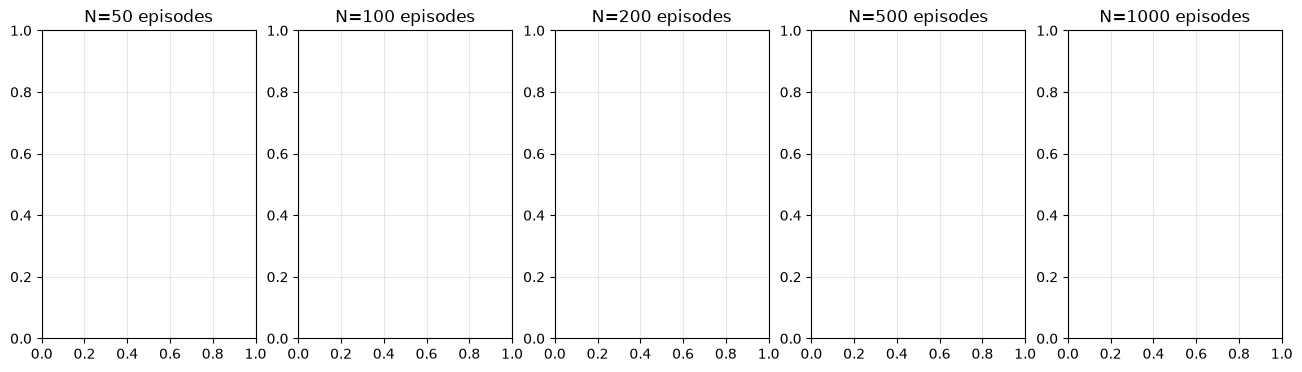

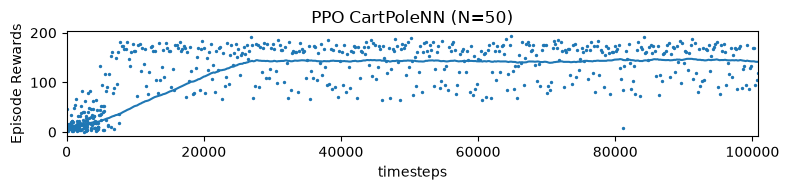

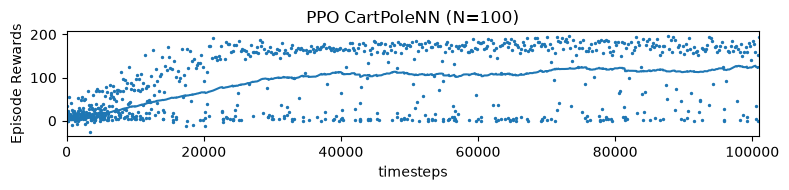

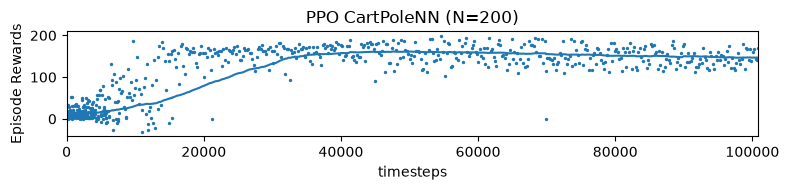

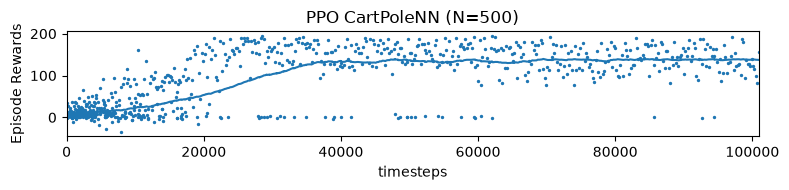

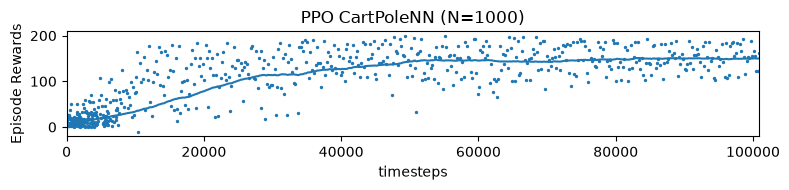

✓ Results plots saved to results-cartpoleNN-comparison.png


In [7]:
# Plot training results for all N values
fig, axes = plt.subplots(1, len(dataset_sizes), figsize=(16, 4))

for idx, N in enumerate(dataset_sizes):
    log_dir_N = f"logs_nn_N{N}"
    try:
        results_plotter.plot_results([log_dir_N], time_steps, results_plotter.X_TIMESTEPS, f"PPO CartPoleNN (N={N})")
        axes[idx].set_title(f"N={N} episodes")
        axes[idx].grid(True, alpha=0.3)
    except Exception as e:
        print(f"Could not plot results for N={N}: {e}")

plt.tight_layout()
plt.savefig("results-cartpoleNN-comparison.png", dpi=150)
plt.show()

print("✓ Results plots saved to results-cartpoleNN-comparison.png")

# Model inference: Evaluate policy

### load best policy

In [8]:
# Load all best trained policies
trained_policies = {}

for N in dataset_sizes:
    log_dir_N = f"logs_nn_N{N}"
    try:
        model_path = f"{log_dir_N}/best_model_nn.zip"
        model_ppo = PPO.load(model_path)
        trained_policies[N] = model_ppo
        print(f"✓ Loaded PPO policy for N={N} from {model_path}")
    except Exception as e:
        print(f"✗ Could not load policy for N={N}: {e}")

✓ Loaded PPO policy for N=50 from logs_nn_N50/best_model_nn.zip
✓ Loaded PPO policy for N=100 from logs_nn_N100/best_model_nn.zip
✓ Loaded PPO policy for N=200 from logs_nn_N200/best_model_nn.zip
✓ Loaded PPO policy for N=500 from logs_nn_N500/best_model_nn.zip
✓ Loaded PPO policy for N=1000 from logs_nn_N1000/best_model_nn.zip


### Evaluate on environment from where NN data was sampled from

In [9]:
# ============================================================================
# AUFGABE 3: Standardisierte Evaluation der Policies
# ============================================================================

# 3.1 Feste Startzustände definieren
# ============================================================================
print("\n" + "="*80)
print("AUFGABE 3.1: Define 20 Fixed Starting States")
print("="*80)

# Generate 20 different starting states using different seeds
num_starting_states = 20
starting_states = []

for seed in range(num_starting_states):
    env_temp = gym.make("CartPole-v1")
    state, _ = env_temp.reset(seed=seed)
    starting_states.append(state.copy())
    env_temp.close()

print(f"✓ Generated {len(starting_states)} fixed starting states")
print(f"  First state: {starting_states[0]}")
print(f"  Last state: {starting_states[-1]}")

# 3.2 & 3.3: Fair Evaluation - All Policies on Same Starting States
# ============================================================================
print("\n" + "="*80)
print("AUFGABE 3.2 & 3.3: Fair Comparison with Standardized Evaluation")
print("="*80)

evaluation_results = {}

for N in dataset_sizes:
    if N not in trained_policies:
        print(f"⚠ Policy for N={N} not available, skipping evaluation")
        continue
    
    print(f"\nEvaluating policy trained on N={N} dynamic model...")
    print(f"  Testing on {num_starting_states} standardized starting states...")
    
    # Create real CartPole environment (no normalization wrapper for this evaluation)
    env_real = gym.make("CartPole-v1", render_mode=None)
    
    # Evaluate on all 20 starting states
    episode_lengths = []
    episode_rewards = []
    
    for state_idx, initial_state in enumerate(starting_states):
        # Call reset() first to satisfy TimeLimit wrapper, then set our desired state
        env_real.reset()
        env_real.unwrapped.state = initial_state.copy()
        state = initial_state.copy()
        done = False
        episode_length = 0
        episode_reward = 0.0
        
        while not done and episode_length < 500:  # CartPole max length is 500
            episode_length += 1
            
            # Get action from policy (without normalization, using raw state)
            action, _states = trained_policies[N].predict(state, deterministic=True)
            
            # Take step in environment
            state, reward, terminated, truncated, _ = env_real.step(action)
            done = terminated or truncated
            episode_reward += reward
        
        episode_lengths.append(episode_length)
        episode_rewards.append(episode_reward)
    
    # Calculate statistics
    avg_length = np.mean(episode_lengths)
    std_length = np.std(episode_lengths)
    max_length = np.max(episode_lengths)
    min_length = np.min(episode_lengths)
    avg_reward = np.mean(episode_rewards)
    
    evaluation_results[N] = {
        'lengths': episode_lengths,
        'rewards': episode_rewards,
        'avg_length': avg_length,
        'std_length': std_length,
        'max_length': max_length,
        'min_length': min_length,
        'avg_reward': avg_reward
    }
    
    print(f"  ✓ Results for N={N}:")
    print(f"    Average episode length: {avg_length:.2f} ± {std_length:.2f} steps")
    print(f"    Range: {min_length:.0f} - {max_length:.0f} steps")
    print(f"    Average reward: {avg_reward:.2f}")
    
    env_real.close()

# Print comprehensive comparison table
print(f"\n{'='*80}")
print("EVALUATION SUMMARY - Standardized Comparison")
print(f"{'='*80}")
print(f"{'N':>6} | {'Avg Length':>12} | {'Std Dev':>10} | {'Max':>6} | {'Min':>6} | {'Avg Reward':>12}")
print("-" * 70)

for N in dataset_sizes:
    if N in evaluation_results:
        r = evaluation_results[N]
        print(f"{N:>6} | {r['avg_length']:>12.2f} | {r['std_length']:>10.2f} | {r['max_length']:>6.0f} | {r['min_length']:>6.0f} | {r['avg_reward']:>12.2f}")

# Ranking
print(f"\n{'='*80}")
print("PERFORMANCE RANKING")
print(f"{'='*80}")

ranking = sorted(evaluation_results.items(), key=lambda x: x[1]['avg_length'], reverse=True)
for rank, (N, results) in enumerate(ranking, 1):
    print(f"{rank}. N={N:4d}: {results['avg_length']:6.2f} avg steps (σ={results['std_length']:5.2f})")


AUFGABE 3.1: Define 20 Fixed Starting States
✓ Generated 20 fixed starting states
  First state: [ 0.01369617 -0.02302133 -0.04590265 -0.04834723]
  Last state: [-0.00796212  0.04258693 -0.022613   -0.04399514]

AUFGABE 3.2 & 3.3: Fair Comparison with Standardized Evaluation

Evaluating policy trained on N=50 dynamic model...
  Testing on 20 standardized starting states...
  ✓ Results for N=50:
    Average episode length: 50.75 ± 32.72 steps
    Range: 28 - 174 steps
    Average reward: 50.75

Evaluating policy trained on N=100 dynamic model...
  Testing on 20 standardized starting states...
  ✓ Results for N=100:
    Average episode length: 32.25 ± 20.80 steps
    Range: 11 - 77 steps
    Average reward: 32.25

Evaluating policy trained on N=200 dynamic model...
  Testing on 20 standardized starting states...
  ✓ Results for N=200:
    Average episode length: 58.20 ± 2.89 steps
    Range: 54 - 65 steps
    Average reward: 58.20

Evaluating policy trained on N=500 dynamic model...
  T

# Aufgabe 4: Gesamtauswertung und Diskussion

## 4.1 Ergebnisdarstellung

In [12]:
# AUFGABE 4.1: Tabelle - Datenmenge N vs. mittlere Policy-Performanz (+ Std)
results_df = pd.DataFrame([
    {'N': N, 'mean_length': r['avg_length'], 'std_length': r['std_length']}
    for N, r in evaluation_results.items()
]).set_index('N')
results_df


,mean_length,std_length
N,,
50,50.75,32.715249
100,32.25,20.796334
200,58.20,2.891366
500,110.90,32.620392
1000,65.60,2.497999


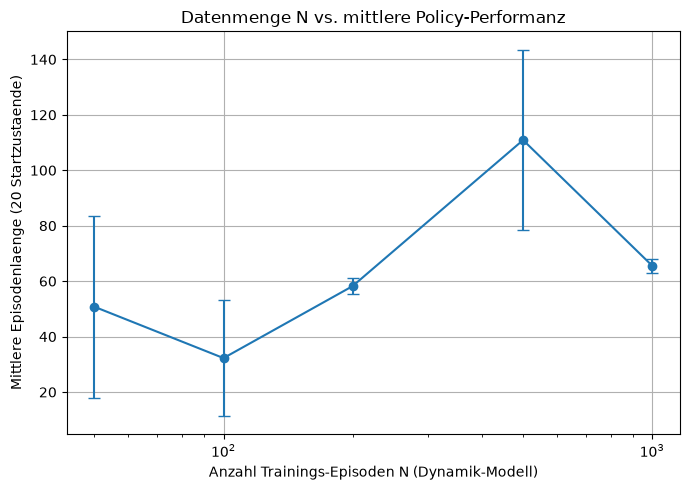

In [13]:
# AUFGABE 4.1: Diagramm - N (x) vs. mittlere Performanz (y), mit Std.-Abweichung
fig, ax = plt.subplots(figsize=(7,5))
ax.errorbar(results_df.index, results_df['mean_length'], yerr=results_df['std_length'],
            marker='o', capsize=4)
ax.set_xscale('log')
ax.set_xlabel('Anzahl Trainings-Episoden N (Dynamik-Modell)')
ax.set_ylabel('Mittlere Episodenlaenge (20 Startzustaende)')
ax.set_title('Datenmenge N vs. mittlere Policy-Performanz')
ax.grid(True)
plt.tight_layout()
plt.savefig('policy_performance_vs_N.png')
plt.show()


## 4.2 Vergleich Modellqualität vs. Policyqualität

Führt den mittleren Rollout-Fehler aus Aufgabe 1 (`rollout_summary_all_N.csv`) mit der Policy-Performanz aus Aufgabe 3 zusammen. Passe den Dateinamen/Spaltennamen an, falls euer Aufgabe-1-Notebook die Datei anders benannt hat.

In [15]:
# AUFGABE 4.2: Zukunftsgeneralisierung (Aufgabe 1) mit Policy-Performanz (Aufgabe 3) zusammenfuehren
rollout_summary = pd.read_csv('rollout_summary_all_N.csv', index_col='N')
combined_df = rollout_summary[['mae_overall']].join(results_df)
combined_df


,mae_overall,mean_performance,std_performance
N,,,
50,0.005611,472.70,46.719482
100,0.030178,500.00,0.000000
200,0.012375,483.85,70.396218
500,0.010853,500.00,0.000000
1000,0.002705,500.00,0.000000


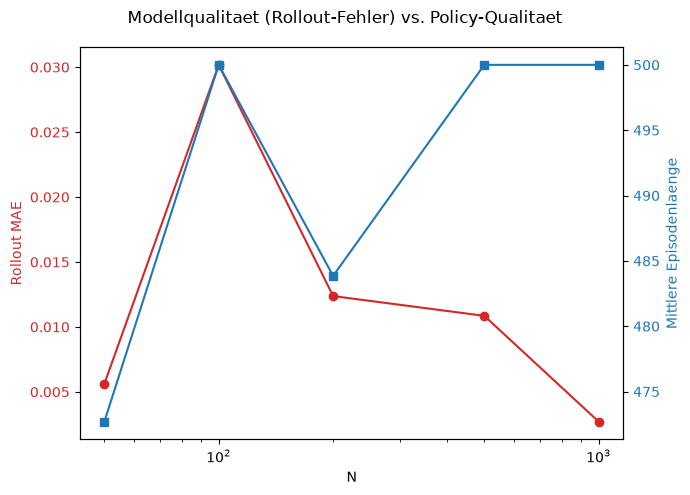

In [17]:
# AUFGABE 4.2: Modellqualitaet vs. Policyqualitaet visualisieren
fig, ax1 = plt.subplots(figsize=(7,5))
ax1.plot(combined_df.index, combined_df['mae_overall'], color='tab:red', marker='o', label='Rollout MAE (Aufgabe 1)')
ax1.set_xlabel('N')
ax1.set_ylabel('Rollout MAE', color='tab:red')
ax1.set_xscale('log')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.plot(combined_df.index, combined_df['mean_performance'], color='tab:blue', marker='s', label='Policy performance (Aufgabe 3)')
ax2.set_ylabel('Mittlere Episodenlaenge', color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.suptitle('Modellqualitaet (Rollout-Fehler) vs. Policy-Qualitaet')
fig.tight_layout()
plt.savefig('model_vs_policy_quality.png')
plt.show()
